<a href="https://colab.research.google.com/github/Sunidhishree/flyrank-ml-internship1/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Sunidhishree/flyrank-ml-internship1"
REPO_DIR = "flyrank-ml-internship1"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

import pandas as pd, numpy as np, json
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
feat_cols = ["impressions_90d", "ctr", "avg_position", "days_since_last_update"]
clean = df[df["avg_position"] > 0].dropna(subset=feat_cols).copy()
scaler = StandardScaler()
X = scaler.fit_transform(clean[feat_cols])
km = KMeans(n_clusters=4, random_state=42, n_init=10)
clean["cluster"] = km.fit_predict(X)

centroids = clean.groupby("cluster")[feat_cols].mean()
print(centroids)

         impressions_90d        ctr  avg_position  days_since_last_update
cluster                                                                  
0          111853.040767   0.337842     10.597122               59.354916
1            3261.944409   0.360054     16.823563               18.930512
2            5149.743640   0.249503     17.909160              105.958620
3               4.913907  37.563444      6.825828               34.503311


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Each of the four clusters maps to one primary action. The mapping is based on: staleness (→ REFRESH), CTR-vs-position mismatch (→ FIX_METADATA), disproportionate traffic value (→ PROTECT_MONITOR), and small-sample CTR noise (→ EXCLUDE_FROM_CTR_REVIEW). Within each action, pages are ranked by impressions_90d, since higher-traffic pages carry more weight regardless of which action bucket they fall into.

In [2]:
# Placeholder — update mapping once real centroids are confirmed
mapping = {
    0: ("FIX_METADATA", "LOW_CTR_GOOD_POSITION"),
    1: ("REFRESH", "STALE_HIGH_VISIBILITY"),
    2: ("PROTECT_MONITOR", "HIGH_VALUE_LOW_RISK_TOLERANCE"),
    3: ("EXCLUDE_FROM_CTR_REVIEW", "SMALL_SAMPLE_NOISE"),
}
def assign_action(row):
    action, reason = mapping.get(row["cluster"], ("NO_ACTION", "NONE"))
    return pd.Series({"action": action, "reason_code": reason})

actions = clean.apply(assign_action, axis=1)
playbook = pd.concat([clean[["content_id"] + feat_cols + ["cluster"]], actions], axis=1)
playbook = playbook.sort_values("impressions_90d", ascending=False).reset_index(drop=True)
playbook.head(20)

,content_id,impressions_90d,ctr,avg_position,days_since_last_update,cluster,action,reason_code
0,content_5fe46e04994d,517715,0.14,4.2,104,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
1,content_aaef01a50def,517109,0.25,5.4,22,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
2,content_8c19996aa890,509252,0.15,2.5,20,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
3,content_2cb567c3c89b,497727,0.10,22.2,48,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
4,content_4c36c775b818,463103,0.41,2.3,20,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
5,content_2dba2b1f9536,443434,0.21,27.9,104,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
6,content_1a9e894be2e2,416180,0.23,4.0,22,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
7,content_2c2606c5d176,347399,0.53,4.2,104,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
8,content_db5989a78dd3,345111,0.21,5.4,20,0,FIX_METADATA,LOW_CTR_GOOD_POSITION
9,content_44e481c8f55b,312694,0.65,1.4,20,0,FIX_METADATA,LOW_CTR_GOOD_POSITION


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: A weekly triage aid for a content strategist with limited review capacity — a starting shortlist grounded in observed behavioral clustering, not an automated decision system.

Limits: Cluster assignments reflect one time window and four surface signals only. They say nothing about content quality, competitive context, or search-intent shifts. Validated under a client-grouped split (silhouette 0.560 vs. 0.511 random — held up well, per w06), but this is still one dataset window, and archetypes may shift as content and search behavior evolve. The "unreliable CTR" archetype is a caution flag, not a behavioral insight — its members should be excluded from CTR-based decisions entirely.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Every recommendation requires human review before action. Nothing here should trigger an automated content or metadata change.

What should never be automated:

Auto-rewriting or unpublishing content based on cluster assignment alone
Auto-editing titles/metadata without human sign-off
Treating REFRESH as license for major changes without first checking why a page is declining (seasonal? competitive? genuinely stale?)
Using this playbook as an individual/team performance metric
Trusting any recommendation for the low-volume/unreliable-CTR cluster as real behavioral signal

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Re-run clustering monthly, or after any bulk content push that could shift the days_since_last_update distribution. Watch for silhouette drift: if k=4's score drops meaningfully below the ~0.51–0.56 range established here, archetypes may no longer reflect current behavior. Flag any cluster whose size changes more than ~30% between runs for manual review before trusting new assignments.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

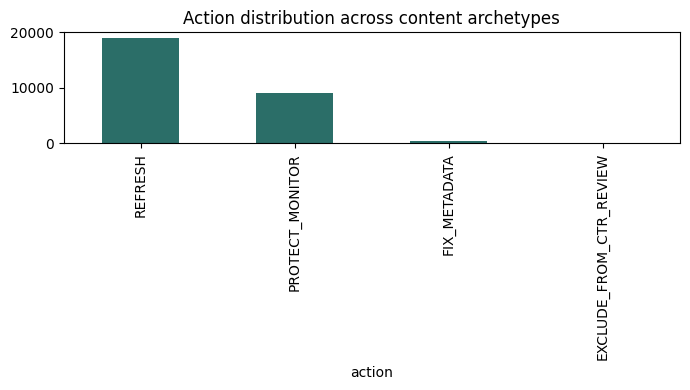

Exported queue, metrics JSON, and figure.


In [3]:
playbook.to_csv("work/outputs/action_playbook_queue.csv", index=False)

metrics = {
    "k": 4,
    "silhouette_random_split": 0.511,
    "silhouette_grouped_split": 0.560,
    "n_total": len(playbook),
    "action_counts": playbook["action"].value_counts().to_dict(),
    "centroids": centroids.round(3).to_dict()
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,4))
playbook["action"].value_counts().plot(kind="bar", ax=ax, color="#2B6E68")
ax.set_title("Action distribution across content archetypes")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()

print("Exported queue, metrics JSON, and figure.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.